# TurboAttention across architectures

Demonstrates that swapping the SDPA step (via `ALL_ATTENTION_FUNCTIONS`) is architecture-agnostic — RoPE, QK-norm, GQA, and any other pre/post processing keeps working because we hook in *after* the model's attention forward has already prepared Q/K/V.

Three models, increasing in complexity:

| Model | Params | Position | QK-norm | KV grouping |
|---|---|---|---|---|
| `gpt2` | 124M | learned positional | no | MHA |
| `HuggingFaceTB/SmolLM2-135M` | 135M | RoPE | no | MHA |
| `Qwen/Qwen3-0.6B` | 600M | RoPE | **yes** | **GQA** |

Sizes aren't perfectly matched (no QK-norm model exists in the 100M class), but the comparison is about architecture flexibility, not headline numbers.

In [1]:
import os
import sys

# Make sibling src/ importable.
_src = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if _src not in sys.path:
    sys.path.insert(0, _src)

import gc
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer

from turbo_attn import TurboQuantKVCache, install_turbo_attention

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
DTYPE = torch.float32
print(f"device={DEVICE}, dtype={DTYPE}")

/Users/dhruvkapur/anaconda3/envs/turboattn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device=mps, dtype=torch.float32


## Helper: load → swap → forward → compare

One forward pass on a long-ish prompt with the original model (reference logits), then re-run after `install_turbo_attention`. The cache is sized to the prompt length and reset before the swapped forward.

**Asymmetric K/V budgets.** K errors propagate through softmax (non-linear, sharp), so K wants a conservative budget. V errors get averaged by `attn @ V` and Lloyd-Max centroids are unbiased per-coordinate, so V tolerates aggressive quantization without shifting argmax. Default here: `k_bits=4, v_bits=2` — about 27% smaller than symmetric `bits=4` at no top-1 cost on most models.

Note on GQA: our cache stores K/V at *kv-head* granularity (matching what HF would actually allocate), so reported compression is apples-to-apples.

In [ ]:
def evaluate(model_name: str, prompt: str,
             k_bits: int = 4, v_bits: int = 2, m: int | None = None):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name, torch_dtype=DTYPE, attn_implementation="eager",
    ).to(DEVICE).eval()
    cfg = model.config

    n_layers   = getattr(cfg, "num_hidden_layers", None) or cfg.n_layer
    n_q_heads  = getattr(cfg, "num_attention_heads", None) or cfg.n_head
    n_kv_heads = getattr(cfg, "num_key_value_heads", n_q_heads)
    hidden     = getattr(cfg, "hidden_size", None) or cfg.n_embd
    head_dim   = getattr(cfg, "head_dim", None) or (hidden // n_q_heads)

    inputs = tok(prompt, return_tensors="pt").to(DEVICE)
    T = inputs.input_ids.shape[-1]

    with torch.no_grad():
        ref_logits = model(**inputs, use_cache=False).logits

    cache = TurboQuantKVCache(
        num_layers=n_layers, batch_size=1,
        num_heads=n_q_heads, num_kv_heads=n_kv_heads,
        head_dim=head_dim,
        k_bits=k_bits, v_bits=v_bits, m=m if m is not None else head_dim,
        seed=42, device=DEVICE, dtype=DTYPE,
    )
    n_attached = install_turbo_attention(model, cache)
    cache.reset()
    with torch.no_grad():
        quant_logits = model(**inputs, use_cache=False).logits

    fp_bytes_kv = 2 * n_layers * 1 * n_kv_heads * T * head_dim * 2  # K+V * fp16, kv-head
    quant_bytes = cache.bytes_total()
    cos = F.cosine_similarity(ref_logits, quant_logits, dim=-1).mean().item()
    top1 = (ref_logits.argmax(-1) == quant_logits.argmax(-1)).float().mean().item()
    top5_ref = ref_logits.topk(5, dim=-1).indices
    top5_q   = quant_logits.topk(5, dim=-1).indices
    top5 = ((top5_ref.unsqueeze(-1) == top5_q.unsqueeze(-2)).any(-1).float().mean().item())

    result = {
        "model": model_name,
        "layers": n_layers,
        "q_heads": n_q_heads,
        "kv_heads": n_kv_heads,
        "head_dim": head_dim,
        "tokens": T,
        "k_bits": k_bits,
        "v_bits": v_bits,
        "attached": n_attached,
        "fp16_KiB": fp_bytes_kv / 1024,
        "turbo_KiB": quant_bytes / 1024,
        "compression": fp_bytes_kv / quant_bytes,
        "cos_sim": cos,
        "top1": top1,
        "top5": top5,
    }
    print(f"\n=== {model_name}  (k_bits={k_bits}, v_bits={v_bits}) ===")
    print(f"  layers / q_heads / kv_heads / head_dim : {n_layers} / {n_q_heads} / {n_kv_heads} / {head_dim}")
    print(f"  attached cache to                       : {n_attached} attention modules")
    print(f"  prompt tokens                           : {T}")
    print(f"  fp16 KV cache (kv-head granularity)     : {result['fp16_KiB']:.1f} KiB")
    print(f"  TurboQuant KV cache                     : {result['turbo_KiB']:.1f} KiB")
    print(f"  compression                             : {result['compression']:.2f}x")
    print(f"  logit cosine sim                        : {cos:.4f}")
    print(f"  top-1 token agreement                   : {top1 * 100:.1f}%")
    print(f"  top-5 token overlap                     : {top5 * 100:.1f}%")

    del model, cache
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result


PROMPT = (
    "The quick brown fox jumps over the lazy dog. "
    "She sells sea shells by the sea shore. "
    "How much wood would a woodchuck chuck if a woodchuck could chuck wood. "
) * 6

## 1. GPT-2 — vanilla SDPA, no RoPE

The simplest case: positional info is added once via `wpe` before the transformer stack, so the `c_attn` projection produces Q/K/V that flow straight into SDPA. Nothing exotic before our hook.

In [3]:
r_gpt2 = evaluate("gpt2", PROMPT)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 23510.85it/s]



=== gpt2  (k_bits=4, v_bits=2) ===
  layers / q_heads / kv_heads / head_dim : 12 / 12 / 12 / 64
  attached cache to                       : 12 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 8028.0 KiB
  TurboQuant KV cache                     : 1881.6 KiB
  compression                             : 4.27x
  logit cosine sim                        : 0.7031
  top-1 token agreement                   : 92.8%
  top-5 token overlap                     : 60.5%


## 2. SmolLM2-135M — RoPE

RoPE is applied to Q and K *inside* the attention forward, before SDPA. Our hook sees post-rotary Q and K, so it just works.

In [4]:
r_smol = evaluate("HuggingFaceTB/SmolLM2-135M", PROMPT)

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 8383.86it/s]



=== HuggingFaceTB/SmolLM2-135M  (k_bits=4, v_bits=2) ===
  layers / q_heads / kv_heads / head_dim : 30 / 9 / 3 / 64
  attached cache to                       : 30 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 5017.5 KiB
  TurboQuant KV cache                     : 1176.0 KiB
  compression                             : 4.27x
  logit cosine sim                        : 0.7031
  top-1 token agreement                   : 83.9%
  top-5 token overlap                     : 57.9%


## 3. Qwen3-0.6B — RoPE + QK-norm + GQA

Qwen3 RMS-norms Q and K *per head* before applying RoPE, plus runs grouped-query attention (kv-heads < q-heads). The hook still sees `[B, H, T, D]` Q/K/V — fully prepared — and the cache stores at kv-head granularity, expanding only at attention time.

QK-norm forces K to have unit RMS per coordinate, which makes the softmax sharper and amplifies any K-side IP-estimation noise through the non-linearity. So we bump `k_bits` from 4 → 6 here. V stays at 2 bits (still gets averaged by `attn @ V`).

In [5]:
r_qwen = evaluate("Qwen/Qwen3-0.6B", PROMPT, k_bits=6, v_bits=2)

Loading weights: 100%|██████████| 311/311 [00:01<00:00, 267.11it/s]



=== Qwen/Qwen3-0.6B  (k_bits=6, v_bits=2) ===
  layers / q_heads / kv_heads / head_dim : 28 / 16 / 8 / 128
  attached cache to                       : 28 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 24976.0 KiB
  TurboQuant KV cache                     : 6829.4 KiB
  compression                             : 3.66x
  logit cosine sim                        : 0.7732
  top-1 token agreement                   : 81.6%
  top-5 token overlap                     : 48.4%


## Summary

In [6]:
rows = [r_gpt2, r_smol, r_qwen]
header = (
    f"{'model':<32} {'L':>3} {'q_h':>4} {'kv_h':>4} {'D':>4} {'T':>4} "
    f"{'k/v':>5} {'fp16 KiB':>9} {'turbo KiB':>10} {'ratio':>6} {'cos':>6} {'top-1':>6}"
)
print(header)
print("-" * len(header))
for r in rows:
    kv = f"{r['k_bits']}/{r['v_bits']}"
    print(
        f"{r['model']:<32} {r['layers']:>3} {r['q_heads']:>4} {r['kv_heads']:>4} {r['head_dim']:>4} "
        f"{r['tokens']:>4} {kv:>5} {r['fp16_KiB']:>9.1f} {r['turbo_KiB']:>10.1f} {r['compression']:>5.2f}x "
        f"{r['cos_sim']:>6.3f} {r['top1']*100:>5.1f}%"
    )

model                              L  q_h kv_h    D    T   k/v  fp16 KiB  turbo KiB  ratio    cos  top-1
--------------------------------------------------------------------------------------------------------
gpt2                              12   12   12   64  223   4/2    8028.0     1881.6  4.27x  0.703  92.8%
HuggingFaceTB/SmolLM2-135M        30    9    3   64  223   4/2    5017.5     1176.0  4.27x  0.703  83.9%
Qwen/Qwen3-0.6B                   28   16    8  128  223   6/2   24976.0     6829.4  3.66x  0.773  81.6%


## V-bit sweep at fixed K-bit

K controls inner-product accuracy (errors propagate through softmax) so it wants a careful budget. V errors get averaged by `attn @ V` and Lloyd-Max is unbiased per-coordinate, so V can usually be cut without shifting argmax.

Sweep `v_bits ∈ {1, 2, 3, 4}` at fixed `k_bits=4` on gpt2 (fastest model). Watch top-1 token agreement vs cosine similarity — they tell different stories.

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 20638.24it/s]



=== gpt2  (k_bits=4, v_bits=1) ===
  layers / q_heads / kv_heads / head_dim : 12 / 12 / 12 / 64
  attached cache to                       : 12 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 8028.0 KiB
  TurboQuant KV cache                     : 1630.7 KiB
  compression                             : 4.92x
  logit cosine sim                        : 0.9163
  top-1 token agreement                   : 82.5%
  top-5 token overlap                     : 51.5%


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 21199.99it/s]



=== gpt2  (k_bits=4, v_bits=2) ===
  layers / q_heads / kv_heads / head_dim : 12 / 12 / 12 / 64
  attached cache to                       : 12 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 8028.0 KiB
  TurboQuant KV cache                     : 1881.6 KiB
  compression                             : 4.27x
  logit cosine sim                        : 0.7031
  top-1 token agreement                   : 92.8%
  top-5 token overlap                     : 60.5%


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 18208.82it/s]



=== gpt2  (k_bits=4, v_bits=3) ===
  layers / q_heads / kv_heads / head_dim : 12 / 12 / 12 / 64
  attached cache to                       : 12 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 8028.0 KiB
  TurboQuant KV cache                     : 2132.4 KiB
  compression                             : 3.76x
  logit cosine sim                        : 0.7265
  top-1 token agreement                   : 91.0%
  top-5 token overlap                     : 65.9%


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 25260.72it/s]



=== gpt2  (k_bits=4, v_bits=4) ===
  layers / q_heads / kv_heads / head_dim : 12 / 12 / 12 / 64
  attached cache to                       : 12 attention modules
  prompt tokens                           : 223
  fp16 KV cache (kv-head granularity)     : 8028.0 KiB
  TurboQuant KV cache                     : 2383.3 KiB
  compression                             : 3.37x
  logit cosine sim                        : 0.7703
  top-1 token agreement                   : 93.7%
  top-5 token overlap                     : 66.6%

v_bits  turbo KiB  ratio  cos sim  top-1
--------------------------------------------
     1     1630.7  4.92x   0.9163  82.5%
     2     1881.6  4.27x   0.7031  92.8%
     3     2132.4  3.76x   0.7265  91.0%
     4     2383.3  3.37x   0.7703  93.7%


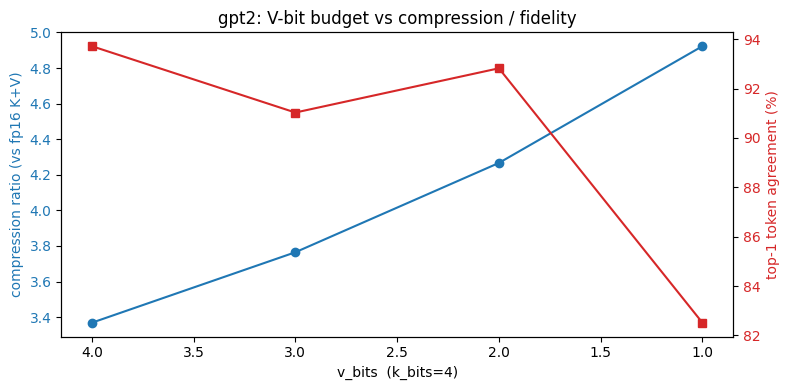

In [8]:
sweep_rows = []
for v in (1, 2, 3, 4):
    sweep_rows.append(evaluate("gpt2", PROMPT, k_bits=4, v_bits=v))

print()
print(f"{'v_bits':>6} {'turbo KiB':>10} {'ratio':>6} {'cos sim':>8} {'top-1':>6}")
print("-" * 44)
for r in sweep_rows:
    print(f"{r['v_bits']:>6} {r['turbo_KiB']:>10.1f} {r['compression']:>5.2f}x "
          f"{r['cos_sim']:>8.4f} {r['top1']*100:>5.1f}%")

fig, ax1 = plt.subplots(figsize=(8, 4))
vs = [r['v_bits'] for r in sweep_rows]
ratios = [r['compression'] for r in sweep_rows]
top1s  = [r['top1'] * 100 for r in sweep_rows]

ax1.plot(vs, ratios, marker="o", color="C0", label="compression x")
ax1.set_xlabel("v_bits  (k_bits=4)")
ax1.set_ylabel("compression ratio (vs fp16 K+V)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")
ax1.invert_xaxis()  # smaller v_bits on the right (more compression)

ax2 = ax1.twinx()
ax2.plot(vs, top1s, marker="s", color="C3", label="top-1 agreement %")
ax2.set_ylabel("top-1 token agreement (%)", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")

ax1.set_title("gpt2: V-bit budget vs compression / fidelity")
plt.tight_layout()
plt.show()